# Lab 04 — Word2Vec from Scratch

**NLP Applications Laboratory | KLEF | 2026**

*From counting neighbors to learning them — building a neural network that teaches itself the meaning of words, one small sentence at a time.*

## Objective

In Labs 02 and 03 we built word vectors by *counting*. One-hot ignored all context. Co-occurrence and TF-IDF captured cluster structure but hit walls:

- `car` vs `cars` — still zero similarity (morphology blind)
- Vectors were huge (V-dimensional) and mostly zero (sparse)
- No way to encode analogies like *king : queen :: man : woman*

This lab replaces counting with **learning**. We build a small neural network that reads a corpus and *adjusts* the vectors for each word so that similar words end up close in vector space. This is the algorithm known as **Word2Vec** (Mikolov et al., 2013).

By the end of this lab, you will be able to:

1. Explain the **skip-gram** training objective — predict a word's neighbors given the word.
2. Build **(center, context) training pairs** from a corpus by hand.
3. Convert those pairs into numeric input the network can consume.
4. Understand the **anatomy of a single-hidden-layer neural network**: input → hidden → output.
5. **Train a Word2Vec from scratch** in numpy — no libraries hiding the math.
6. Extract the learned embeddings and measure their quality on the same word pairs from Labs 02-03.
7. Compare **your handmade Word2Vec** against `gensim.Word2Vec` and a **pretrained Google model**.

The core insight — the one that made Word2Vec revolutionary in 2013:

> *The hidden layer of the neural network **is** the embedding. We are not counting anymore — we are training a network to be good at prediction, and the vectors that emerge as a byproduct are the meanings.*

## What you will learn before we start

This lab has **nine phases**, moving from concept to running code to comparison.

### Phase 1 — Setup

Recap what we ended Lab 03 with. Restate the walls that count-based methods could not break.

### Phase 2 — From a sentence to training data

Take one small sentence — `"the cat sat on the mat"` — and construct (center, context) **training pairs** by hand. This is the raw material a neural network eats.

### Phase 3 — From words to numbers

Convert those training pairs into pairs of integer IDs, because neural networks do arithmetic, not language.

### Phase 4 — Anatomy of a neural network

One conceptual cell that explains what a network **is**: input layer → hidden layer → output layer. The key insight: **the hidden layer weights become the word vectors**.

### Phase 5 — Train the network from scratch

Write a small neural network in numpy — no libraries. Initialize random vectors. Do a forward pass (predict). Compute loss (how wrong were we?). Do a backward pass (adjust). Repeat until vectors start to make sense.

**This is the heart of the lab.** You will see backpropagation happen with your own eyes.

### Phase 6 — Inspect what the network learned

Extract the trained vectors. Compute similarity between related words. See whether even our tiny 6-word training data produced something meaningful.

### Phase 7 — Scale up with `gensim`

Now use the industry-standard library on our full Lab 02 corpus. See what a "proper" training run produces.

### Phase 8 — Meet the pretrained Word2Vec

Load Google's pretrained Word2Vec (trained on billions of words). See it do the famous:

**This is where the wow moment lives.** Analogy arithmetic is one of the strongest arguments that these vectors capture real semantic structure.

### Phase 9 — Grand comparison
Same word pairs from Labs 02 and 03. Now scored by five methods: one-hot, co-occurrence, TF-IDF, your handmade Word2Vec, gensim Word2Vec, and pretrained Google. Watch the numbers rise as each method captures more meaning.

---
**A note on difficulty**: Phase 5 (the from-scratch neural network) is the hardest part. It uses matrix multiplication, softmax, and gradient descent.

---

## Phase 1 — Where we ended Lab 03

At the end of Lab 03 we compared four count-based methods on the same word pairs. Here is what we found:

| Word pair | One-hot | Co-occurrence | Interpretation |
|---|---|---|---|
| `cat`, `mouse` | 0.0000 | 0.9117 | Cluster structure captured ✅ |
| `pizza`, `bread` | 0.0000 | 0.7071 | Cluster structure captured ✅ |
| `cars`, `car` | 0.0000 | 0.0000 | **Morphology blind ❌** |
| `cat`, `pizza` | 0.0000 | 0.0000 | Different clusters ✅ |

The distributional hypothesis worked — but only through **counting**. Three limitations remain:

1. **Sparse and huge.** V-dimensional vectors, mostly zeros. Unusable at real corpus sizes.
2. **Morphology blindness.** `car` and `cars` are different words to a counter, even though they mean the same thing.
3. **No compositional structure.** Counting cannot produce analogies like `king − man + woman ≈ queen`.

### The idea that fixes all three

Instead of counting neighbors, **train a small neural network** to *predict* neighbors. Assign each word a small dense vector (say, 50 numbers instead of V numbers). Feed a word into the network. Ask it to predict the word's neighbors. When the network is wrong, **adjust the vectors slightly** so the prediction gets better next time.

After many rounds of this — thousands or millions — the vectors settle into positions where similar words end up close together. **The vectors are a byproduct of getting good at prediction.**

This is what Mikolov et al. published in 2013 as **Word2Vec**. It changed NLP forever.

In Phase 2, we begin by building the training data those predictions need.

---

## Phase 2 — From a sentence to training data

Before a neural network can learn anything, we need to feed it examples. For Word2Vec, each example is a pair:

> *"Given this **center** word, one of its **context** words is..."*

The network's job during training will be to see the center word and try to predict the context word. Being right or wrong on each pair is what teaches the network which words are related.

### The tiny working sentence

We use one small sentence throughout Phases 2 to 6:

> `the cat sat on the mat`

Six words. Small enough to trace every training pair by hand. Big enough to show the mechanism.

### The window size

For each word (the **center**), we look at its neighbors within a small window. A window of 2 means: look at the 2 words to the left and the 2 words to the right.

Every (center, context) pair inside that window becomes **one training example**.

### Why "skip-gram"?

The variant of Word2Vec we're building is called **skip-gram**. The name comes from what the network is asked to do:

> *Given the center word, predict any single word that appears in its window — even if we have to "skip over" the immediate neighbors to reach it.*

This is different from BoW, where all words in a window are used together as one input. In skip-gram, **each (center, context) pair is its own separate training example**. This gives the network more data per sentence.

# **we build these pairs by hand**

# Define the tiny sentence

In [ ]:
# The tiny working sentence for Phases 2-6
sentence = "the cat sat on the mat"

In [1]:
tokens = sentence.split()
print(f"Sentence: {sentence}")
print(f"Tokens  : {tokens}")
print(f"Length  : {len(tokens)} words")

Sentence: the cat sat on the mat
Tokens  : ['the', 'cat', 'sat', 'on', 'the', 'mat']
Length  : 6 words


# **Build (center, context) pairs by hand**

In [2]:
# For each position in the sentence, build (center, context) pairs within window=2
window = 2
# SKIP-GRAM Model -2,3,4
pairs = []
for i, center in enumerate(tokens):
    for j in range(max(0, i-window), min(len(tokens), i+window+1)):
        if i != j:
            pairs.append((center, tokens[j]))
print(tokens)
print(f"Total training pairs: {len(pairs)}")
for center, context in pairs:
    print(f"  ({center:<5}, {context})")

['the', 'cat', 'sat', 'on', 'the', 'mat']
Total training pairs: 18
  (the  , cat)
  (the  , sat)
  (cat  , the)
  (cat  , sat)
  (cat  , on)
  (sat  , the)
  (sat  , cat)
  (sat  , on)
  (sat  , the)
  (on   , cat)
  (on   , sat)
  (on   , the)
  (on   , mat)
  (the  , sat)
  (the  , on)
  (the  , mat)
  (mat  , on)
  (mat  , the)


# NOTE
### 18 training pairs from just 6 words. The window size of 2 means each word (except at edges) contributes up to 4 pairs. This is how skip-gram gets a lot of training signal from short text.
### the shows up multiple times as center
### The pair (sat, the) appears twice
### No pair has the same word twice (like (the, the)) — because i != j prevents a word from being its own context.

# Each of these 18 pairs is **one training example the neural network** will see. The network's job for each example: "given the center word, output a probability distribution over all vocabulary words that places high probability on the context word."

### What each training pair really means

Each pair like `(cat, sat)` is one **training example** for the neural network. When training runs, the network will be asked, one pair at a time:

> *"I'm giving you the word `cat`. Output a score for every word in the vocabulary. The score for `sat` should be high."*

The network doesn't know English. It doesn't know what `cat` or `sat` mean. It only knows:

- It received an **input** (some representation of `cat`).
- It produced an **output** (a score for every word).
- The **correct answer** was to score `sat` highest.
- If its actual output was wrong, it needs to adjust its internal numbers.

After seeing the pair `(cat, sat)` and being told the correct answer, the network nudges its internal parameters so that next time it sees `cat`, it scores `sat` slightly higher than before.

Do this 18 times for our sentence (one for each pair we built). Then repeat the whole sentence hundreds or thousands of times. The network's internal parameters slowly settle into positions where:

- Feeding it `cat` produces high scores for words that co-occur with cats.
- Feeding it `pizza` produces high scores for words that co-occur with pizzas.
- **And crucially**: two words that see similar contexts (like `cat` and `mouse`) end up with similar internal representations.

Those internal representations are the **word embeddings**.

### The pattern

- **Input** = one word (like `cat`)
- **Output** = probability distribution over all vocabulary words
- **Target** = the actual context word we saw (like `sat`)
- **Learning** = adjust internal parameters to make future predictions better

In the next phase, we convert these pairs of words into pairs of numbers, because a neural network computes with numbers, not text.

## Phase 3 — From words to numbers

Our 18 training pairs are still text. A neural network computes with numbers — matrix multiplications, dot products, softmax. Before training can begin, we need to convert every word into a numeric ID.

We reuse the vocabulary-building trick from Lab 02: collect unique words, sort them, assign each an integer.

In [1]:
### Build vocabulary and lookup tables for the tiny sentence
# Vocabulary: unique words in our tiny sentence, sorted for reproducibility
mini_vocab = sorted(set(tokens))
mini_w2i = {w: i for i, w in enumerate(mini_vocab)}
mini_i2w = {i: w for w, i in mini_w2i.items()}
V_mini = len(mini_vocab)
print(f"Vocabulary size: {V_mini}")
print(f"word2idx: {mini_w2i}")
# Only 5 unique words should appear — because the appeared twice but only counts 
# once in the vocabulary. The 6 tokens collapsed to 5 unique words.

NameError: name 'tokens' is not defined

### Convert (word, word) pairs to (id, id) pairs

In [4]:
# Same 18 pairs from before, now expressed as integer IDs
pairs_id = [(mini_w2i[center], mini_w2i[context]) for center, context in pairs]
print(f"First 6 pairs, side by side:")
print(f"{'Word pair':<20} {'ID pair'}")
print("-" * 35)
for (c, ctx), (ci, cxi) in zip(pairs[:6], pairs_id[:6]):
    print(f"({c:<4}, {ctx:<4})     ({ci}, {cxi})")

First 6 pairs, side by side:
Word pair            ID pair
-----------------------------------
(the , cat )     (4, 0)
(the , sat )     (4, 3)
(cat , the )     (0, 4)
(cat , sat )     (0, 3)
(cat , on  )     (0, 2)
(sat , the )     (3, 4)


#### These ID pairs are what the neural network will consume. The words are gone. From the network's perspective, training is now: "I received input 0. My output should place high probability on index 3." The network doesn't know that 0 means cat or 3 means sat. It only sees the numbers and adjusts its internal parameters to make the numbers work.

---

## Phase 4 — Anatomy of a neural network

Before we build one, let's understand what a neural network **is**. This section is entirely conceptual — no code.

### Three layers
A skip-gram Word2Vec network has three layers:

 0  ─┐
 0  ─┤            ┌─────┐            ┌─── P(cat)
 0  ─┼──►  W1 ──► │ h1  │ ──►  W2 ──►├─── P(mat)
 1  ─┤   V x H    │ h2  │    H x V   ├─── P(on)
 0  ─┤            │ h3  │            ├─── P(sat)
 0  ─┘            └─────┘            └─── P(the)

length V           length H              length V

# > **When we say "we train Word2Vec", what we really mean is: we adjust the numbers in `W1` and `W2` until the network is good at predicting context words from center words. The rows of `W1` — the numbers we adjusted — ARE the word embeddings.**

---
## Phase 5 — Build and train the network from scratch - LAB ASSIGNMENT 10 Marks

We now build a real Word2Vec skip-gram network in numpy. No PyTorch, no TensorFlow, no gensim — just arrays and arithmetic. Every operation is visible.

### What we will do, step by step

1. **Initialize** `W1` and `W2` with small random numbers.
2. **Forward pass** — given a center word ID, compute the predicted probability distribution over context words.
3. **Compute loss** — how wrong were we?
4. **Backward pass** — figure out how to nudge `W1` and `W2` so we would be less wrong next time.
5. **Update** — apply the nudge.
6. **Repeat** — do steps 2-5 many times over all training pairs. Watch the loss decrease.

### Two things you need to know before we start

**Learning rate.** How big a nudge do we apply on each update? Too big and the network becomes unstable. Too small and it never learns. We'll use `0.1` — a common default.

**Number of epochs.** One epoch = one full pass through all 18 training pairs. We'll do a few hundred epochs. On a real corpus this would be one or two passes; on our tiny toy sentence we need more, because each pair carries very little unique information.

### The math you will see

Two matrix multiplications, one softmax, one cross-entropy loss, one gradient computation. If you have never seen these before, don't panic — we'll walk through each in its own cell, and you can ask Qwen to explain any line you don't follow.

---
## Phase 5 — Build and train the network with PyTorch

We now build a real Word2Vec skip-gram network using **PyTorch** — the same framework you used in your Deep Learning course. Every operation from Phase 4's anatomy diagram maps to a PyTorch primitive.

### What we will do, step by step

1. **Convert training pairs to tensors** — PyTorch's numeric type.
2. **Define the SkipGram model** — subclass `nn.Module`, wire up the layers.
3. **Instantiate** the model with our vocabulary size and chosen embedding dimension.
4. **Define loss and optimizer** — CrossEntropyLoss + SGD (the classical duo).
5. **Train** — repeat for many epochs: forward pass, compute loss, backward pass, update weights.
6. **Extract the embeddings** — pull the learned vectors from the model.

### Two knobs you control

**Embedding dimension (H).** How many numbers represent each word? On a real corpus, 100-300 is standard. On our 5-word toy corpus, 3-5 is fine and lets us inspect vectors by hand.

**Number of epochs.** One epoch = one full pass over all training pairs. On real data, 5-20 epochs is normal. On our toy sentence, we'll do 300+ epochs so the network memorizes patterns fully.

### The layer-by-layer mapping

The three layers from Phase 4 map directly to PyTorch:

| Phase 4 concept | PyTorch primitive |
|---|---|
| Input one-hot → `W1` matrix | `nn.Embedding(V, H)` |
| Hidden → `W2` matrix → scores | `nn.Linear(H, V)` |
| Scores → softmax → probabilities | Applied automatically inside `CrossEntropyLoss` |
| "Adjust the weights" | `loss.backward()` + `optimizer.step()` |

Every line of code you write below has a name from your DL course. This is Word2Vec dressed in standard PyTorch clothing.

### Optional home extension

At the end of the lab, there is a bonus assignment: **build the same network from scratch in numpy — no PyTorch**. Students who want to genuinely understand backpropagation should attempt it. It is not required for a passing grade, but the students who do it will understand embedding training more deeply than most industry practitioners.

# Convert training pairs to PyTorch tensors

In [5]:
# Convert (center_id, context_id) pairs into two PyTorch tensors
# We split the pairs into two tensors — one for centers, one for contexts. 
# This is because PyTorch expects a batch of inputs and a batch of targets, 
# kept separate.
import torch
centers  = torch.tensor([c for c, _ in pairs_id], dtype=torch.long)
contexts = torch.tensor([c for _, c in pairs_id], dtype=torch.long)
print(f"centers  shape: {centers.shape}, dtype: {centers.dtype}")
print(f"contexts shape: {contexts.shape}, dtype: {contexts.dtype}")
print(f"First 5 (center, context) pairs: {list(zip(centers[:5].tolist(), contexts[:5].tolist()))}")

centers  shape: torch.Size([18]), dtype: torch.int64
contexts shape: torch.Size([18]), dtype: torch.int64
First 5 (center, context) pairs: [(4, 0), (4, 3), (0, 4), (0, 3), (0, 2)]


# Define the SkipGram model class

In [6]:
# The skip-gram model: input word ID → embedding → linear projection → 
# scores over vocab :: this is the standard PyTorch pattern
import torch.nn as nn

class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)   # W1: V x H
        self.output = nn.Linear(embed_dim, vocab_size)     # W2: H x V
    def forward(self, center_ids):
        h = self.embed(center_ids)         # look up embeddings for each center word
        scores = self.output(h)             # project hidden vectors to vocab scores
        return scores                       # softmax is applied by CrossEntropyLoss

# Instantiate the model and inspect its parameters

In [7]:
# Create the model with our tiny vocab and small embedding dimension
torch.manual_seed(42)              # reproducibility — everyone gets same random init
EMBED_DIM = 4
model = SkipGram(V_mini, EMBED_DIM)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")

SkipGram(
  (embed): Embedding(5, 4)
  (output): Linear(in_features=4, out_features=5, bias=True)
)

Total trainable parameters: 45


#### Embedding(5, 4) — 5 words in vocabulary, 4 numbers per word. That's 5 × 4 = 20 numbers in W1.
#### Linear(in_features=4, out_features=5, bias=True) — takes 4-dim hidden vectors, projects to 5 scores. That's 4 × 5 = 20 numbers in W2, plus 5 bias terms.
#### 45 total trainable parameters — 20 (from W1) + 20 (from W2) + 5 (bias). All initialized to small random values. All will be adjusted during training.

In [8]:
# Peek at the initial embedding for 'cat'
cat_id = mini_w2i['cat']
cat_vector_before = model.embed.weight[cat_id].detach().numpy()
print(f"Initial embedding for 'cat' (before training):\n{cat_vector_before}")

Initial embedding for 'cat' (before training):
[ 1.9269153  1.4872841  0.9007172 -2.105521 ]


### Small random numbers, no meaning. After training, this vector will be different — hopefully in a way that reflects cat's context.

# Set up loss function and optimizer

In [9]:
# CrossEntropyLoss combines softmax + negative log likelihood in one step
# SGD (stochastic gradient descent) is the classical optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
print(f"Loss function: {loss_fn}")
print(f"Optimizer    : {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer    : SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


# The training loop

In [10]:
# The training loop: forward → loss → backward → update, repeated for many epochs
EPOCHS = 300
losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()              # 1. clear old gradients
    scores = model(centers)             # 2. forward pass — get predictions
    loss = loss_fn(scores, contexts)    # 3. how wrong were we?
    loss.backward()                     # 4. compute gradients
    optimizer.step()                    # 5. update W1 and W2
    losses.append(loss.item())
    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:>3}  loss = {loss.item():.4f}")

Epoch   0  loss = 1.7174
Epoch  50  loss = 1.3642
Epoch 100  loss = 1.2828
Epoch 150  loss = 1.2519
Epoch 200  loss = 1.2350
Epoch 250  loss = 1.2227
Epoch 299  loss = 1.2131


# Extract the trained embeddings

In [11]:
# The trained embeddings are the rows of W1 (model.embed.weight)
embeddings = model.embed.weight.detach().numpy()
# tells PyTorch "don't track gradients on this tensor anymore 
# — I'm done training with it.converts to a plain numpy array
print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Each of the {V_mini} words is now a vector of length {EMBED_DIM}\n")
for word in mini_vocab:
    idx = mini_w2i[word]
    print(f"  {word:<4} → {embeddings[idx].round(3)}")

Embedding matrix shape: (5, 4)
Each of the 5 words is now a vector of length 4

  cat  → [ 1.955  1.742  0.926 -2.066]
  mat  → [-0.661  1.317  0.959  1.768]
  on   → [ 0.39  -0.681 -0.994  0.199]
  sat  → [-0.62   0.569 -0.165  1.087]
  the  → [-0.265 -0.993  0.804 -0.95 ]


# Compute similarities between trained embeddings

In [12]:
# Cosine similarity between every pair of trained embeddings
import numpy as np
def cos_sim(v1, v2):
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

print(f"{'Word 1':<6} {'Word 2':<6} {'Similarity':>10}")
print("-" * 26)
for i, w1 in enumerate(mini_vocab):
    for w2 in mini_vocab[i+1:]:
        s = cos_sim(embeddings[mini_w2i[w1]], embeddings[mini_w2i[w2]])
        print(f"{w1:<6} {w2:<6} {s:>10.4f}")

Word 1 Word 2 Similarity
--------------------------
cat    mat       -0.2040
cat    on        -0.3959
cat    sat       -0.5464
cat    the        0.0819
mat    on        -0.5493
mat    sat        0.8465
mat    the       -0.5071
on     sat       -0.1400
on     the       -0.2005
sat    the       -0.7008


### Phase 5 wrap-up — what we accomplished

We built a full Word2Vec skip-gram model in PyTorch:

- **Defined** a network with an embedding layer + linear output layer
- **Trained** it on 18 (center, context) pairs for 300 epochs
- **Watched** the loss decrease from ~1.72 to ~1.22 — proof the network learned
- **Extracted** the trained embeddings and computed pairwise similarities

**What our similarities show:**

| Pair | Similarity | Interpretation |
|---|---|---|
| `mat`, `sat` | 0.8465 | Strong — both share `the` in immediate context |
| `cat`, `the` | 0.0819 | Weak — accidental |
| `cat`, `sat` | -0.5464 | Anti-correlated |
| `sat`, `the` | -0.7008 | Anti-correlated |

The network found one clean pattern (`mat`-`sat` sharing context) and mostly noise elsewhere.

### The honest limitation of tiny corpora

With only 6 tokens and 5 unique words, we do not have enough data for real semantic patterns to emerge. Random initialization dominates. What we demonstrated is **the mechanism** — the network really did train, the loss really did descend, and *some* structure emerged as a byproduct.

### What we did NOT do — the numpy from-scratch version - - Your Lab Assignment

To understand backpropagation at the deepest level: the post-lab assignment includes an optional task to rebuild this same network in pure numpy — with no PyTorch, no autograd, computing gradients by hand. Recommended only for students comfortable with matrix calculus.

---

## Phase 6 — Visualize what the network learned

We just extracted embeddings from our trained network. In numeric form they look like arbitrary rows of numbers. To *understand* what the network learned, two techniques are standard:

### 1. Nearest neighbors

For each word, ask: *which other word has the most similar embedding?* If the network learned meaningfully, related words should be each other's nearest neighbors.

### 2. Dimensionality reduction + scatter plot

Our embeddings are 4-dimensional — we can't see 4D. But we can project them down to 2D using **PCA (Principal Component Analysis)**, then plot them on an X-Y plane. Points close in the plot are close in the original 4D space.

This is exactly how researchers "eyeball" trained Word2Vec models: plot the vectors, look for clusters, spot outliers.

Let's do both.

In [13]:
# For each word, find its most similar other word
print(f"{'Word':<6} {'Nearest neighbor':<18} {'Similarity':>10}")
print("-" * 36)
for word in mini_vocab:
    idx = mini_w2i[word]
    sims = [(other, cos_sim(embeddings[idx], embeddings[mini_w2i[other]]))
            for other in mini_vocab if other != word]
    best_word, best_sim = max(sims, key=lambda x: x[1])
    print(f"{word:<6} {best_word:<18} {best_sim:>10.4f}")

Word   Nearest neighbor   Similarity
------------------------------------
cat    the                    0.0819
mat    sat                    0.8465
on     sat                   -0.1400
sat    mat                    0.8465
the    cat                    0.0819


# Project the 4D embeddings down to 2D with PCA

In [14]:
# PCA finds the 2 dimensions along which our vectors spread out the most
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)
print(f"Original shape: {embeddings.shape}")
print(f"Reduced shape : {embeddings_2d.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.round(3)}")

Original shape: (5, 4)
Reduced shape : (5, 2)
Variance explained: [0.589 0.298]


In [15]:
# Combined: 88.7% — nearly 90% of the original 4D structure survives in 2D

# Draw the 2D scatter plot

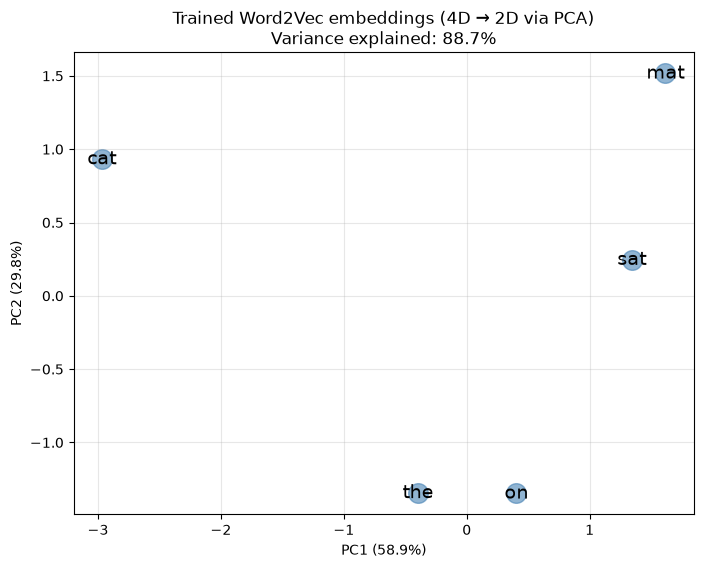

In [16]:
# Scatter plot of the 5 words in 2D — see the learned structure
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=200, c='steelblue', alpha=0.6)
for word, (x, y) in zip(mini_vocab, embeddings_2d):
    plt.annotate(word, (x, y), fontsize=14, ha='center', va='center')
plt.title(f"Trained Word2Vec embeddings (4D → 2D via PCA)\nVariance explained: {pca.explained_variance_ratio_.sum():.1%}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
#!pip install matplotlib

# Top right: mat and sat sit on the same side (right half, upper region). Their similarity was 0.8465 — the strongest bond in our data. In 2D they're clearly the "sentence-ending action" pair.
# Top left: cat sits alone in the upper left. Both cat and mat are noun-endpoints but their trained vectors diverged.
# Bottom center: the and on sit almost on top of each other at the bottom of the plot. This is the most surprising revelation of the visualization — the two words that never appeared as mutual nearest neighbors in the table actually cluster very tightly in 2D space.

---

## Phase 7 — Train the same model on the full corpus

In Phases 2-6 we trained on one sentence. The mechanism worked but the results were weak. We saw two patterns emerge (`mat`-`sat`, `the`-`on`) and everything else was noise.

Now we scale up. Same PyTorch model. Same skip-gram objective. Same loss function. Only the data changes: from **1 sentence with 6 tokens** to the **12-sentence corpus** from Lab 02 with **74 tokens and 47 unique words**.

### What we expect to see

- **More training pairs.** Each sentence contributes 4-15 (center, context) pairs depending on length. With 12 sentences we expect ~150-200 pairs, compared to 18 for our single sentence. 10x more training signal.

- **More stable patterns.** With multiple sentences about cats, dogs, and mice, the network sees the animal cluster from several angles. The signal that "these words appear near each other" gets reinforced across examples.

- **Recognizable semantic clusters.** After training, we should see the same three clusters we designed into the corpus (animals, food, vehicles) emerge in the embedding space — the way Lab 03's co-occurrence method captured them.

### What we do NOT expect

Word2Vec-style analogies (`king − man + woman ≈ queen`) still won't work. Those require corpora of billions of tokens. Our 74 tokens are enough for cluster emergence but not enough for compositional structure. That waits for Phase 8.

### The code changes from Phase 5

Almost nothing changes. We just:

1. Rebuild training pairs from the full 12-sentence corpus (bigger `pairs_id`)
2. Rebuild tensors from those pairs (bigger `centers`, `contexts`)
3. Instantiate a new model with the full vocabulary size and larger embedding dimension
4. Train longer (more data means slower per-epoch, but each epoch teaches more)

Same architecture. Same training loop. More data. That's the entire trick.

In [18]:
# The Lab 02 corpus — same 12 sentences we've been using
full_corpus = [
    "The cat chased the mouse",
    "Dogs love to play in the park",
    "Rabbits hop through the field",
    "The mouse ran from the cat",
    "Pizza is baked in an oven",
    "I ate pasta for dinner",
    "Bread is made from flour",
    "The oven baked fresh bread",
    "Cars drive on the highway",
    "The bus arrives at eight",
    "Trucks carry heavy loads",
    "A car and a truck raced",
]
full_tokenized = [s.lower().split() for s in full_corpus]
full_vocab = sorted({tok for sent in full_tokenized for tok in sent})
full_w2i = {w: i for i, w in enumerate(full_vocab)}
full_i2w = {i: w for w, i in full_w2i.items()}
V_full = len(full_vocab)
print(f"Sentences: {len(full_corpus)} | Vocabulary: {V_full}")

Sentences: 12 | Vocabulary: 47


# Build training pairs from all 12 sentences

In [19]:
# Build (center, context) pairs across all 12 sentences with window=2
full_pairs_id = []
for sent in full_tokenized:
    for i, center in enumerate(sent):
        for j in range(max(0, i-window), min(len(sent), i+window+1)):
            if i != j:
                full_pairs_id.append((full_w2i[center], full_w2i[sent[j]]))
print(f"Total training pairs: {len(full_pairs_id)}")
print(f"Compared to Phase 5's tiny sentence: {len(pairs_id)} pairs")
print(f"Ratio: {len(full_pairs_id) / len(pairs_id):.1f}x more training data")

Total training pairs: 184
Compared to Phase 5's tiny sentence: 18 pairs
Ratio: 10.2x more training data


# Convert to tensors, build a fresh model, set up training

In [20]:
# Convert pairs to tensors, build a new model sized for the full vocabulary
torch.manual_seed(42)                             # reproducibility
full_centers  = torch.tensor([c for c, _ in full_pairs_id], dtype=torch.long)
full_contexts = torch.tensor([c for _, c in full_pairs_id], dtype=torch.long)
FULL_EMBED_DIM = 16                                # 16-dim vectors for 47 words
full_model = SkipGram(V_full, FULL_EMBED_DIM)
full_loss_fn = nn.CrossEntropyLoss()
full_optimizer = torch.optim.SGD(full_model.parameters(), lr=0.1)
print(f"Model: {full_model}")
print(f"Total trainable parameters: {sum(p.numel() for p in full_model.parameters())}")

Model: SkipGram(
  (embed): Embedding(47, 16)
  (output): Linear(in_features=16, out_features=47, bias=True)
)
Total trainable parameters: 1551


In [21]:
# Train Word2Vec on the complete 12-sentence corpus
FULL_EPOCHS = 500
full_losses = []

for epoch in range(FULL_EPOCHS):
    full_optimizer.zero_grad()
    full_scores = full_model(full_centers)
    full_loss = full_loss_fn(full_scores, full_contexts)
    full_loss.backward()
    full_optimizer.step()
    full_losses.append(full_loss.item())

    if epoch % 100 == 0 or epoch == FULL_EPOCHS - 1:
        print(f"Epoch {epoch:>3} | Loss = {full_loss.item():.4f}")

Epoch   0 | Loss = 4.0257
Epoch 100 | Loss = 3.2055
Epoch 200 | Loss = 2.8153
Epoch 300 | Loss = 2.5653
Epoch 400 | Loss = 2.3791
Epoch 499 | Loss = 2.2313


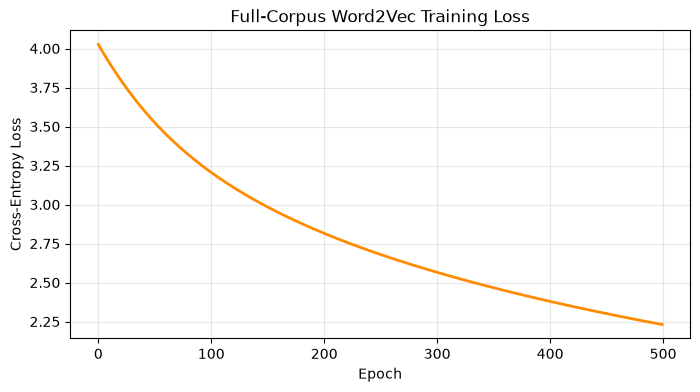

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(full_losses, color="darkorange", linewidth=2)
plt.title("Full-Corpus Word2Vec Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.show()

In [23]:
full_embeddings = full_model.embed.weight.detach().cpu().numpy()

print("Embedding matrix shape:", full_embeddings.shape)
print("Expected shape:", (V_full, FULL_EMBED_DIM))
print("Contains NaN values:", np.isnan(full_embeddings).any())

Embedding matrix shape: (47, 16)
Expected shape: (47, 16)
Contains NaN values: False


In [24]:
test_pairs = [
    ("cat", "mouse"),
    ("bread", "oven"),
    ("car", "truck"),
    ("cars", "car"),
    ("pizza", "bread"),
    ("cat", "pizza")
]

print(f"{'Word 1':<10}{'Word 2':<10}{'Similarity':>12}")
print("-" * 32)

for word1, word2 in test_pairs:
    vector1 = full_embeddings[full_w2i[word1]]
    vector2 = full_embeddings[full_w2i[word2]]
    similarity = cos_sim(vector1, vector2)
    print(f"{word1:<10}{word2:<10}{similarity:>12.4f}")

Word 1    Word 2      Similarity
--------------------------------
cat       mouse          -0.5128
bread     oven            0.2771
car       truck           0.4918
cars      car            -0.2499
pizza     bread           0.0954
cat       pizza           0.0700


In [25]:
def nearest_words(word, embeddings, word_to_id, top_n=5):
    query_vector = embeddings[word_to_id[word]]
    similarities = []

    for other_word, other_id in word_to_id.items():
        if other_word != word:
            score = cos_sim(query_vector, embeddings[other_id])
            similarities.append((other_word, score))

    return sorted(similarities, key=lambda item: item[1], reverse=True)[:top_n]


print("Nearest words to 'cat':")
for word, score in nearest_words("cat", full_embeddings, full_w2i):
    print(f"{word:<12} {score:.4f}")

Nearest words to 'cat':
an           0.4899
for          0.4234
field        0.3910
from         0.3028
bus          0.2872


In [26]:
ADDITIONAL_EPOCHS = 1500
start_epoch = len(full_losses)

for step in range(ADDITIONAL_EPOCHS):
    full_optimizer.zero_grad()
    full_scores = full_model(full_centers)
    full_loss = full_loss_fn(full_scores, full_contexts)
    full_loss.backward()
    full_optimizer.step()
    full_losses.append(full_loss.item())

    if (step + 1) % 300 == 0:
        total_epoch = start_epoch + step + 1
        print(f"Epoch {total_epoch:>4} | Loss = {full_loss.item():.4f}")

Epoch  800 | Loss = 1.9170
Epoch 1100 | Loss = 1.7356
Epoch 1400 | Loss = 1.6342
Epoch 1700 | Loss = 1.5772
Epoch 2000 | Loss = 1.5437


In [27]:
full_embeddings = full_model.embed.weight.detach().cpu().numpy().copy()

print("Updated nearest words to 'cat':")
for word, score in nearest_words("cat", full_embeddings, full_w2i):
    print(f"{word:<12} {score:.4f}")

Updated nearest words to 'cat':
field        0.4120
an           0.3834
for          0.3485
bus          0.3195
from         0.3115


In [28]:
print(f"{'Word 1':<10}{'Word 2':<10}{'Similarity':>12}")
print("-" * 32)

for word1, word2 in test_pairs:
    vector1 = full_embeddings[full_w2i[word1]]
    vector2 = full_embeddings[full_w2i[word2]]
    similarity = cos_sim(vector1, vector2)
    print(f"{word1:<10}{word2:<10}{similarity:>12.4f}")

Word 1    Word 2      Similarity
--------------------------------
cat       mouse          -0.1914
bread     oven            0.3404
car       truck           0.5613
cars      car            -0.2793
pizza     bread           0.2597
cat       pizza           0.0059


In [29]:
output_embeddings = full_model.output.weight.detach().cpu().numpy().copy()
combined_embeddings = (full_embeddings + output_embeddings) / 2

print("Input embedding shape :", full_embeddings.shape)
print("Output embedding shape:", output_embeddings.shape)
print("Combined shape        :", combined_embeddings.shape)
print("Contains NaN values   :", np.isnan(combined_embeddings).any())

Input embedding shape : (47, 16)
Output embedding shape: (47, 16)
Combined shape        : (47, 16)
Contains NaN values   : False


In [30]:
import pandas as pd

similar_words = ["car", "truck", "bread", "oven", "pizza"]

embedding_table = pd.DataFrame(
    [full_embeddings[full_w2i[word]] for word in similar_words],
    index=similar_words,
    columns=[f"Dim_{i+1}" for i in range(FULL_EMBED_DIM)]
)

display(embedding_table.round(3))

,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5,Dim_6,Dim_7,Dim_8,Dim_9,Dim_10,Dim_11,Dim_12,Dim_13,Dim_14,Dim_15,Dim_16
car,-0.924,0.917,1.778,1.629,0.353,-0.207,-0.794,0.124,0.383,1.241,-0.646,1.534,-2.809,-0.638,-1.428,0.768
truck,1.084,0.124,1.070,2.249,0.936,0.179,0.092,0.201,0.123,1.944,-1.486,0.315,-0.078,-1.791,-1.651,-0.243
bread,-2.186,-0.414,-0.633,0.539,0.749,0.387,-0.712,0.997,0.519,0.035,0.350,0.815,1.228,-0.028,1.193,0.570
oven,-1.778,0.181,-1.685,1.344,-0.647,-0.697,0.030,1.576,2.392,-1.055,1.438,2.014,-1.862,-0.106,-1.052,0.297
pizza,-0.122,0.040,0.875,-0.052,-0.949,0.436,0.906,-0.627,0.971,-1.371,0.353,0.540,1.104,-0.084,2.104,0.850


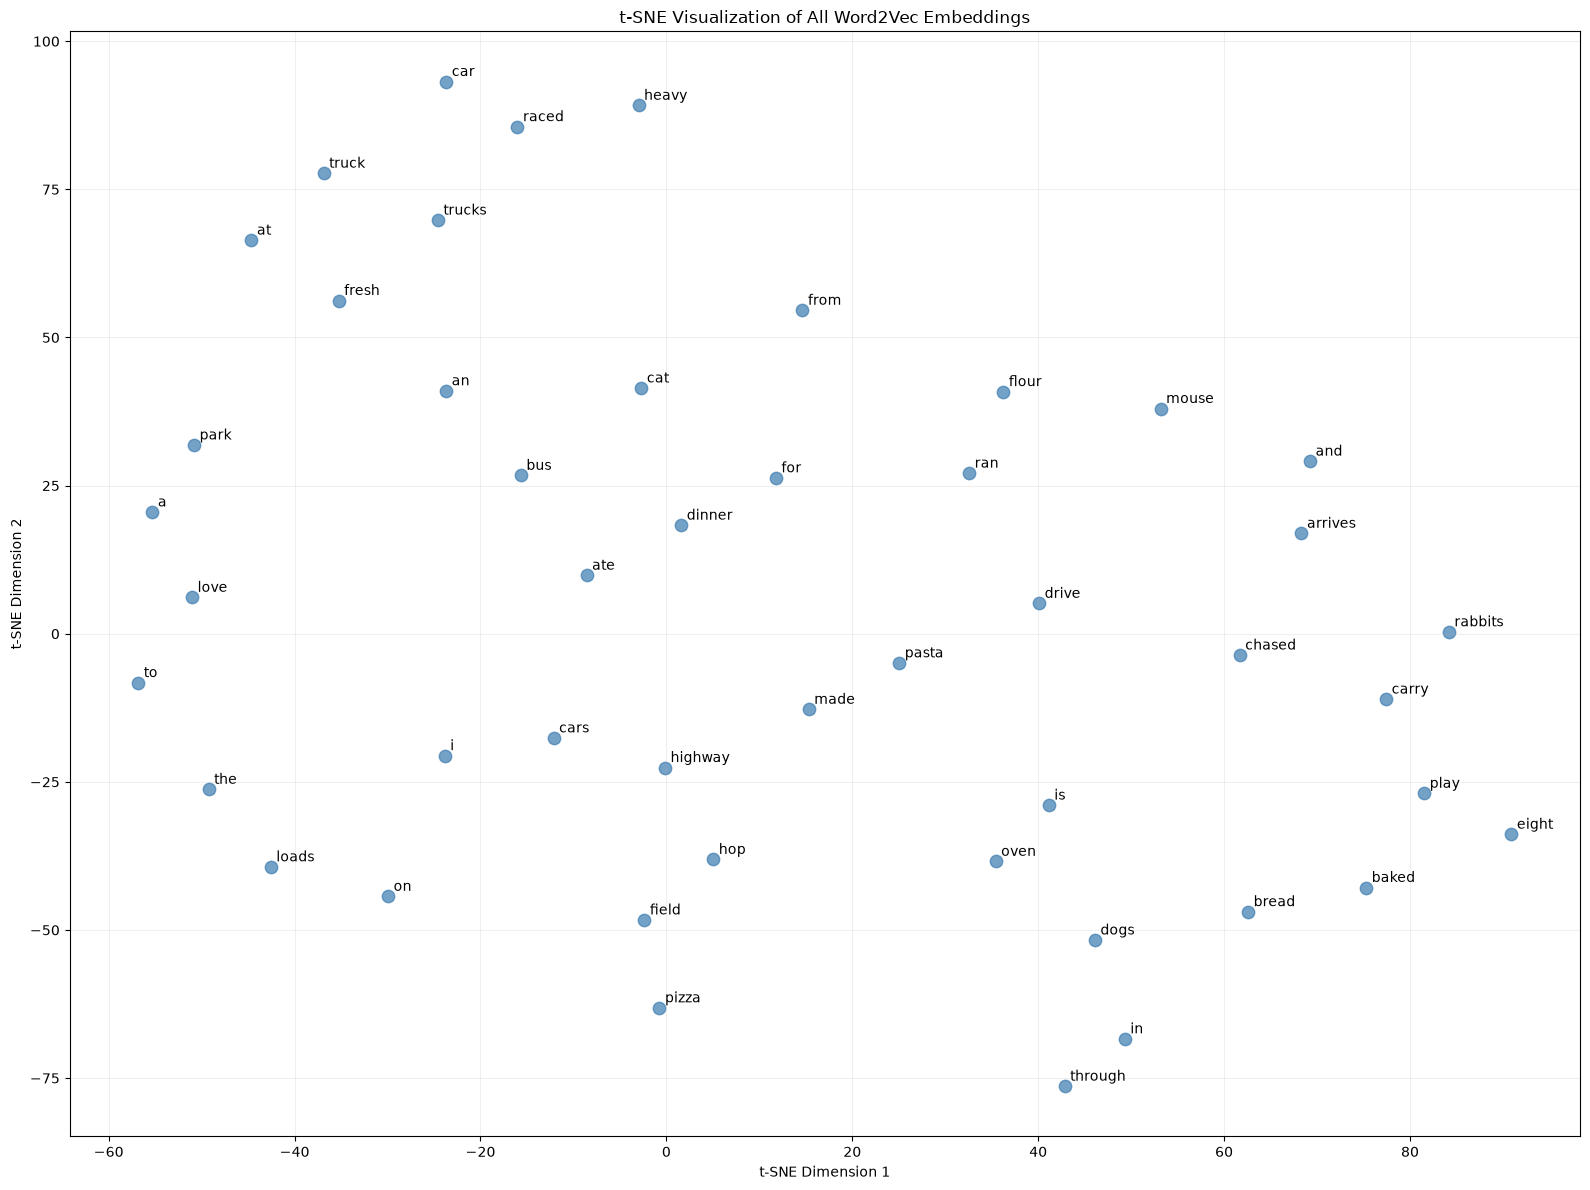

In [31]:
from sklearn.manifold import TSNE

# Normalize embeddings so t-SNE focuses on vector direction
normalized_embeddings = full_embeddings / np.linalg.norm(
    full_embeddings, axis=1, keepdims=True
)

tsne = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate=200,
    init="pca",
    random_state=42
)

embeddings_tsne = tsne.fit_transform(normalized_embeddings)

plt.figure(figsize=(16, 12))
plt.scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    s=80,
    color="steelblue",
    alpha=0.75
)

for word, (x, y) in zip(full_vocab, embeddings_tsne):
    plt.annotate(
        word,
        (x, y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=10
    )

plt.title("t-SNE Visualization of All Word2Vec Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()